# Lecture 1: Your first visualization in VS Code

You are preparing for a brand's weekly marketing meeting. Your manager asks:

> "Over the past 16 weeks, has revenue been growing, flat, or declining? Are we keeping our margin when revenue rises?"

You will load the brand's practice dataset, combine daily records into weekly totals, and draw line charts. Then you will try a daily chart and consider whether that level of detail helps answer the manager's question.

Today's goal is to check that you can open and run a Python notebook in VS Code, see a data table and a chart, and make a small change to a plot. The code is provided; you do not need to write it from scratch.

### Before you begin: VS Code setup

Install VS Code and Python on your computer. Python is a separate program; installing the VS Code extension alone does not install it.

To find and install an extension:

1. In VS Code, click the **Extensions** icon (four squares) in the left sidebar, or press **Ctrl+Shift+X** on Windows / **Cmd+Shift+X** on macOS.
2. Click the **search box at the top of the Extensions panel**. Type the extension name or ID from the table below, such as `ms-python.python`.
3. Select the matching result, check its publisher, and click **Install**. If it is already installed, make sure it is enabled.

Whenever the table says "search," use this Extensions search box in VS Code.

| Extension or tool | For this exercise | Purpose | What to do |
| --- | --- | --- | --- |
| Python (Microsoft), `ms-python.python` | Required | Python language support in VS Code. | Search for `ms-python.python` and click **Install**. Open the Command Palette (Ctrl+Shift+P on Windows; Shift+Cmd+P on macOS), run **Python: Select Interpreter**, and choose your installed Python environment. |
| Jupyter (Microsoft), `ms-toolsai.jupyter` | Required | Open notebooks and run their code cells. | Search for `ms-toolsai.jupyter` and click **Install**. Open this notebook, click **Select Kernel**, and choose the same Python environment. Install `ipykernel` if prompted, then run the setup cell below. |
| Jupyter Notebook Renderers (Microsoft), `ms-toolsai.jupyter-renderers` | Recommended | Display notebook outputs, including charts. | Search for `ms-toolsai.jupyter-renderers` and install or enable it. No sign-in is needed. Run a plotting cell in Section 3 and check that the chart appears below it. |
| GitHub Copilot Chat | Recommended for help; optional for running this notebook | Ask for explanations of code or errors. | Open the Copilot menu and choose **Use AI Features** or the sign-in option shown. Sign in with GitHub and complete authorization in your browser. Follow any extension installation prompts, then open Chat and ask it to explain a code cell. |
| Claude Code for VS Code (Anthropic) | Optional | An alternative AI coding assistant. | Search for **Claude Code** and install the extension published by Anthropic. Open its panel, click **Sign in**, and finish authorization in your browser with an account that has Claude Code access. See the [setup guide](https://code.claude.com/docs/en/vs-code). |
| Codex for VS Code (OpenAI), `openai.chatgpt` | Optional | An alternative AI coding assistant. | Search for `openai.chatgpt` and install the extension published by OpenAI. Open the Codex panel and follow the prompt to sign in with your ChatGPT account. See the [setup guide](https://developers.openai.com/codex/ide) for account and platform requirements. |

For Copilot, use the [VS Code setup guide](https://code.visualstudio.com/docs/setup/copilot). You can apply to [GitHub Education](https://github.com/education/students) using your university email. If you ask an AI assistant for help, read the code it suggests and check the result.

Keep `lecture1.ipynb` and `lecture1.csv` together in the same folder. In VS Code, choose **File > Open Folder** and open that folder, then open this notebook. Click **Select Kernel** at the top right and choose your Python environment. The kernel is the Python process that runs the cells. If VS Code asks to install `ipykernel`, accept.

Run each code cell in order using its triangular Run button. Text cells explain the steps; code cells produce the tables and charts below them. See [Jupyter notebooks in VS Code](https://code.visualstudio.com/docs/datascience/jupyter-notebooks) and [Jupyter Notebook Renderers](https://marketplace.visualstudio.com/items?itemName=ms-toolsai.jupyter-renderers) for setup details.

## 0) Check your setup

This notebook uses pandas to work with tables and Matplotlib to draw charts. If these packages are missing, remove the `#` from the installation line below and run it once. Then run the imports. If prompted, restart the kernel before continuing.

In [1]:
# Run once if pandas or Matplotlib is missing:
# %pip install pandas matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Setup works. You are ready to load the data.")

Setup works. You are ready to load the data.


If you see the setup message, the kernel and imports work. If you get `ModuleNotFoundError`, run the installation line above in this notebook and retry. If cells do not run at all, check that a Python kernel is selected.

## 1) Define the question before plotting

Our task is to summarize performance for a weekly marketing meeting.

- **Question:** Is revenue growing, flat, or declining over the 16 weeks?
- **Metrics:** Total revenue, with margin rate as a check on how much revenue the brand retains as margin.
- **Granularity:** One point per week, combining all four channels. Granularity means the level of detail represented by each observation.
- **Chart:** A line chart to show change over time. Revenue and margin rate go in separate charts because they have different units.

For today, focus on running the cells and connecting each step to what appears in the chart.

## 2) Load and inspect the data

`lecture1.csv` contains synthetic marketing and sales data for a fictional brand. It has 448 rows covering September 1 through December 21, 2025: 112 days across 16 complete weeks. Each row records **one channel on one day**. The channels are Paid Search, Paid Social, Email, and Organic.

The file contains only the six columns used in this notebook:

| Column | Meaning |
| --- | --- |
| `date` | The day of the observation. |
| `week` | The week within this dataset, numbered 1 through 16. |
| `channel` | The marketing channel. |
| `revenue` | Sales revenue for that channel and day, in the dataset's currency units. |
| `margin` | The margin amount recorded for that channel and day, in the same currency units. It is an amount, not a percentage. |
| `promo` | 1 if a promotion is active; 0 otherwise. The flag is repeated across channels on the same day. |

We calculate weekly margin rate as total margin divided by total revenue.

Run the next cell to read the CSV. If you get `FileNotFoundError`, check that the CSV is in the same folder as this notebook and that you opened that folder in VS Code.

In [3]:
df = pd.read_csv("lecture1.csv", parse_dates=["date"])

### Check that the file loaded

`head()` shows the first five rows. Look at `date` and `channel`: several rows belong to the same day because each channel has its own record.

In [4]:
df.head()

,date,week,channel,revenue,margin,promo
0,2025-09-01,1,Paid Search,6410.286736,2634.167486,0
1,2025-09-01,1,Paid Social,520.896521,192.911846,0
2,2025-09-01,1,Email,5660.581734,2771.559634,0
3,2025-09-01,1,Organic,1508.135795,683.947402,0
4,2025-09-02,1,Paid Search,3590.394169,1619.710263,0


The next cell reports the row count, column types, and non-missing values. You should see 448 rows and 6 columns.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     448 non-null    datetime64[us]
 1   week     448 non-null    int64         
 2   channel  448 non-null    str           
 3   revenue  448 non-null    float64       
 4   margin   448 non-null    float64       
 5   promo    448 non-null    int64         
dtypes: datetime64[us](1), float64(2), int64(2), str(1)
memory usage: 21.1 KB


This summary gives a quick view of the columns and their values. It is fine if some statistics are unfamiliar; today's check is that VS Code displays the table.

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,448,NaN,NaN,NaN,2025-10-26 12:00:00,2025-09-01 00:00:00,2025-09-28 18:00:00,2025-10-26 12:00:00,2025-11-23 06:00:00,2025-12-21 00:00:00,NaN
week,448.0,NaN,NaN,NaN,8.5,1.0,4.75,8.5,12.25,16.0,4.614926
channel,448,4,Paid Search,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revenue,448.0,NaN,NaN,NaN,4622.690038,481.162327,2272.893053,4176.34677,6157.216998,17749.676241,2926.039634
margin,448.0,NaN,NaN,NaN,2062.89253,172.28225,922.350341,1800.319865,2783.480693,9149.477982,1409.596726
promo,448.0,NaN,NaN,NaN,0.125,0.0,0.0,0.0,0.0,1.0,0.331089


## 3) Plot weekly revenue and profit margin

First, combine the daily channel records into one row per week. Add up revenue and margin, then divide the totals to get the weekly profit margin rate:

**Weekly profit margin rate = total weekly margin / total weekly revenue.**

Revenue shows how much the brand sells; the margin rate shows how much of that revenue is retained as recorded margin. Use the weekly totals rather than averaging the row-level rates, which would give a small channel the same weight as a large one.


In [7]:
weekly = (
    df.groupby("week", as_index=False)
      .agg(revenue=("revenue", "sum"),
           margin=("margin", "sum"))
)

weekly["margin_rate"] = weekly["margin"] / weekly["revenue"]
weekly.head()

,week,revenue,margin,margin_rate
0,1,106029.244895,47195.908720,0.445122
1,2,108569.021213,48973.752812,0.451084
2,3,116352.959313,52016.624801,0.447059
3,4,150542.938700,67995.197974,0.451666
4,5,130644.049759,58693.591721,0.449263


### Draw the revenue and profit margin charts

Each chart has 16 points, one per week. A profit margin rate of 0.40 means that the recorded margin is 40% of revenue. The charts use separate axes because revenue is an amount and the margin rate is a fraction. Run the cell and check that both charts appear.


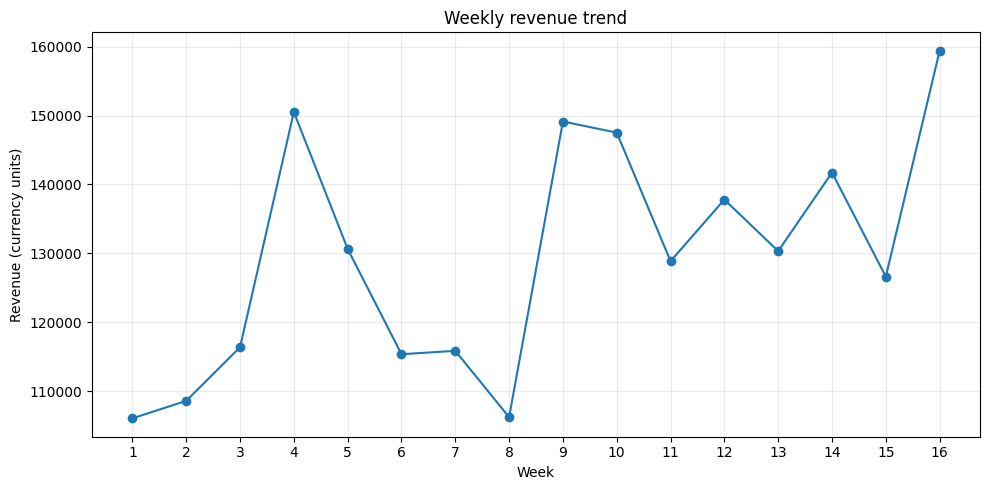

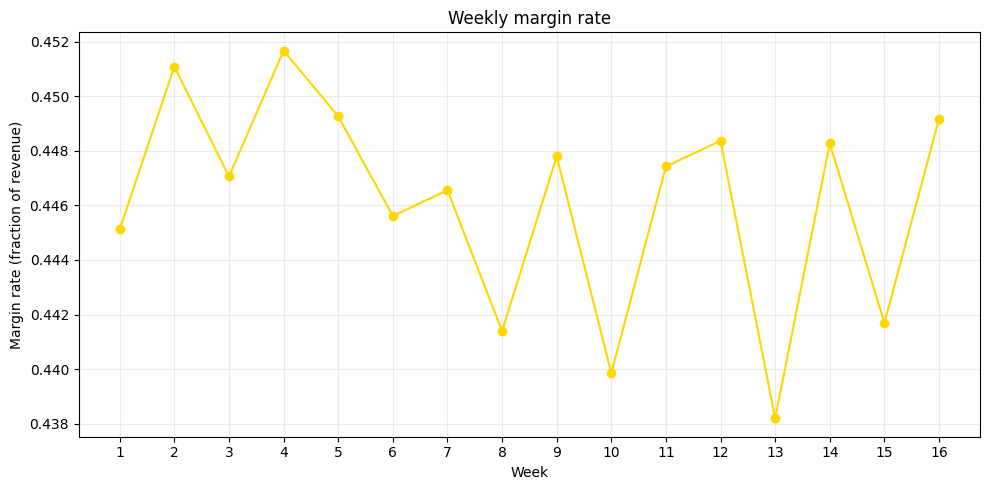

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(weekly["week"], weekly["revenue"], marker="o")
plt.title("Weekly revenue trend")
plt.xlabel("Week")
plt.ylabel("Revenue (currency units)")
plt.xticks(weekly["week"])
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(weekly["week"], weekly["margin_rate"], marker="o", color="gold")
plt.title("Weekly margin rate")
plt.xlabel("Week")
plt.ylabel("Margin rate (fraction of revenue)")
plt.xticks(weekly["week"])
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Read the profit margin chart

The weekly profit margin rate stays between about 43.8% and 45.2%. Revenue changes much more across the 16 weeks, while the share retained as margin stays fairly steady.

For example, compare weeks 8, 9, and 10: revenue rises in week 9, and the margin rate moves from 44.14% to 44.78%, then to 43.99%. Read both charts together to check whether higher sales come with a higher margin rate.

### Add context: promotion weeks

The manager may ask why revenue changes in particular weeks. We can label weeks with at least three promotion days. Count each date once, because the same promotion flag appears in all four channel records.


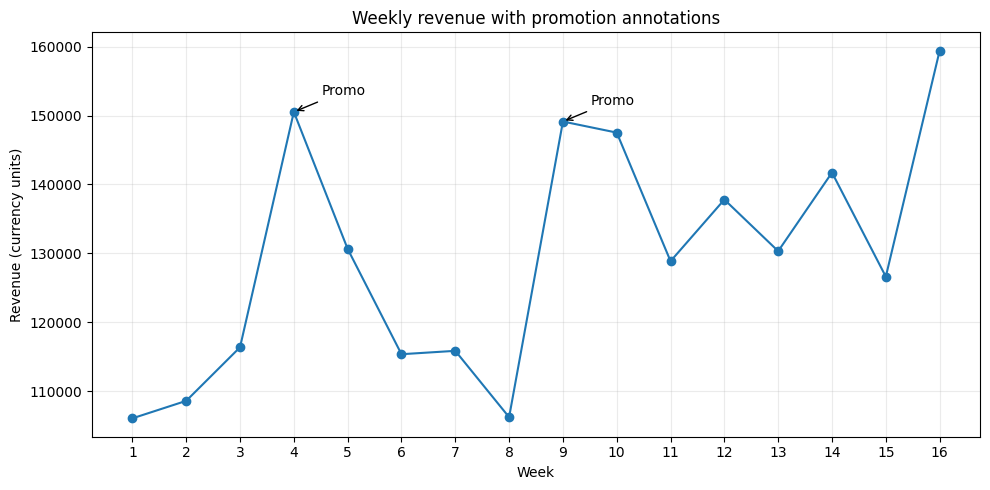

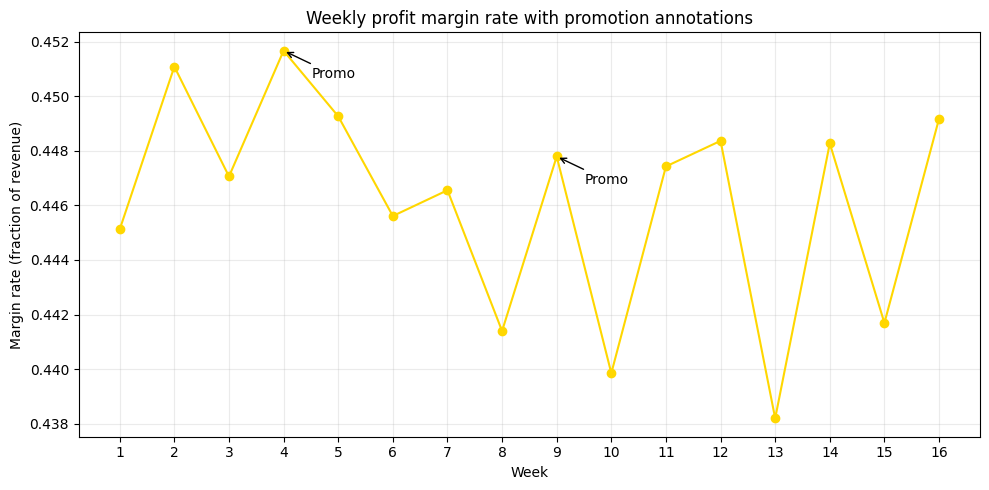

In [9]:
promo_days = (
    df.groupby(["week", "date"], as_index=False)
      .agg(promo=("promo", "max"))
      .groupby("week", as_index=False)
      .agg(promo_days=("promo", "sum"))
)

weekly["promo_days"] = weekly["week"].map(promo_days.set_index("week")["promo_days"])

plt.figure(figsize=(10, 5))
plt.plot(weekly["week"], weekly["revenue"], marker="o")
plt.title("Weekly revenue with promotion annotations")
plt.xlabel("Week")
plt.ylabel("Revenue (currency units)")
plt.xticks(weekly["week"])
plt.grid(True, alpha=0.25)

# Mark weeks with at least three distinct promotion days.
promo_weeks = weekly.loc[weekly["promo_days"] >= 3, "week"].tolist()
for w in promo_weeks:
    y = float(weekly.loc[weekly["week"] == w, "revenue"].iloc[0])
    plt.annotate("Promo", xy=(w, y), xytext=(20, 12),
                 textcoords="offset points",
                 arrowprops=dict(arrowstyle="->", lw=1))

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(weekly["week"], weekly["margin_rate"], marker="o", color="gold")
plt.title("Weekly profit margin rate with promotion annotations")
plt.xlabel("Week")
plt.ylabel("Margin rate (fraction of revenue)")
plt.xticks(weekly["week"])
plt.grid(True, alpha=0.25)

# Mark the same promotion weeks on the margin chart.
for w in promo_weeks:
    y = float(weekly.loc[weekly["week"] == w, "margin_rate"].iloc[0])
    plt.annotate("Promo", xy=(w, y), xytext=(20, -20),
                 textcoords="offset points",
                 arrowprops=dict(arrowstyle="->", lw=1))

plt.tight_layout()
plt.show()


Compare the promotion labels in the two charts. Revenue is higher in the promotion weeks than in the preceding weeks, but the promotions do not appear to change the profit margin rate much in this example. The rate stays around 44-45% throughout the period, including the promotion weeks. Higher sales can increase the total margin amount while leaving the margin rate roughly unchanged.

**Try one edit:** Change the title of either annotated chart and rerun its cell. You should see your new title immediately.


## 4) A bad example: daily detail for a weekly question

Suppose you use one point per day to answer the same question at the weekly meeting. The following code runs correctly, but its granularity is a poor fit for this overview: 112 daily points draw attention to short-term fluctuations.

We still combine all four channels within each day. The change is the time unit: day instead of week.

In [10]:
daily = (
    df.groupby("date", as_index=False)
      .agg(revenue=("revenue", "sum"),
           margin=("margin", "sum"))
)

daily["margin_rate"] = daily["margin"] / daily["revenue"]
daily.head()

,date,revenue,margin,margin_rate
0,2025-09-01,14099.900785,6282.586368,0.445577
1,2025-09-02,11956.332839,5477.822571,0.458152
2,2025-09-03,9942.384874,4251.436484,0.427607
3,2025-09-04,22100.031829,9751.102649,0.441226
4,2025-09-05,18822.178261,8586.667333,0.456199


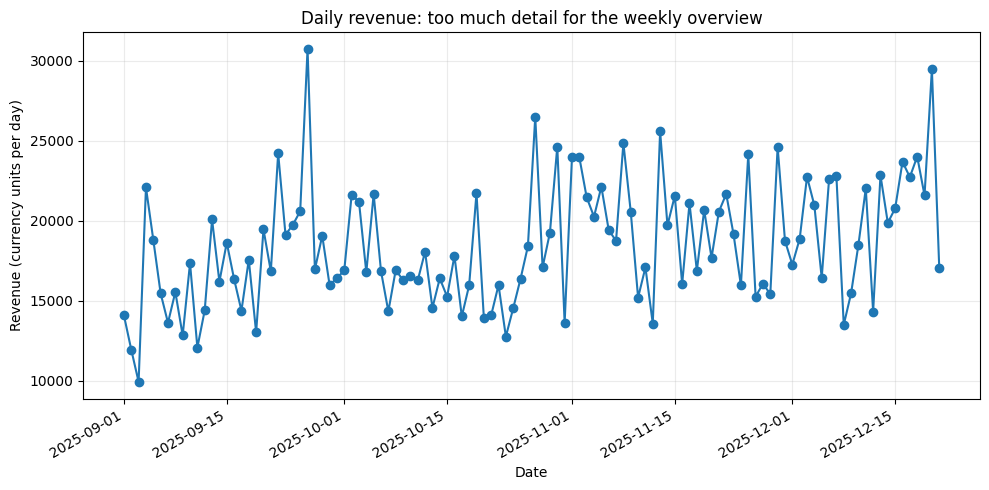

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(daily["date"], daily["revenue"], marker="o")
plt.title("Daily revenue: too much detail for the weekly overview")
plt.xlabel("Date")
plt.ylabel("Revenue (currency units per day)")
plt.xticks(rotation=30, ha="right")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Compare this plot with the weekly revenue chart in Section 3.

- Which chart makes it easier to discuss the pattern across the 16 weeks?
- Which daily ups and downs might distract the manager from that question?
- When would a daily chart help? Consider monitoring a promotion as it happens.

Daily data are useful for daily decisions. Here, the mistake is choosing a level of detail that does not fit the weekly overview. Also, daily and weekly revenue totals cover different lengths of time, so their vertical values are not directly comparable.

### Finish the setup check

Save your notebook. Restart the kernel and choose **Run All** to confirm that it works in order with no variables left over from earlier runs. You are ready for class if the setup message, data tables, weekly charts, and daily chart all appear without errors.
